In [27]:
import pandas as pd

# Ruta del archivo
file_path = '/Users/a4657925/Personal-Repos/Salmon/multiexport_mef-angostura_oxygen_2016-10.xlsx'

# Leer el archivo Excel
data = pd.read_excel(file_path,
                     # set the first row as the header
                     header=2,
                     )

# Mostrar las primeras filas del DataFrame
print(data.columns)
data.head()

Index(['Fecha', 'Hora', 'Oxígeno (mg/l)', 'Temperatura (°C)', 'Saturación (%)',
       'Salinidad (ppm)', 'Fecha.1', 'Hora.1', 'Oxígeno (mg/l).1',
       'Temperatura (°C).1', 'Saturación (%).1', 'Salinidad (ppm).1',
       'Fecha.2', 'Hora.2', 'Oxígeno (mg/l).2', 'Temperatura (°C).2',
       'Saturación (%).2', 'Salinidad (ppm).2'],
      dtype='object')


,Fecha,Hora,Oxígeno (mg/l),Temperatura (°C),Saturación (%),Salinidad (ppm),Fecha.1,Hora.1,Oxígeno (mg/l).1,Temperatura (°C).1,Saturación (%).1,Salinidad (ppm).1,Fecha.2,Hora.2,Oxígeno (mg/l).2,Temperatura (°C).2,Saturación (%).2,Salinidad (ppm).2
0,05/10/2016,00:04:35,8.8,10.4,96.47,32,05/10/2016,00:01:01,9.2,10.2,100.41,32.0,05/10/2016,00:01:01,9.7,10.1,105.63,32.0
1,05/10/2016,00:09:35,9.1,10.4,99.75,32,05/10/2016,00:06:01,9.1,10.2,99.32,32.0,05/10/2016,00:06:01,9.6,10.1,104.54,32.0
2,05/10/2016,00:14:35,9.5,10.5,104.37,32,05/10/2016,00:11:01,9.1,10.2,99.32,32.0,05/10/2016,00:11:01,9.6,10.1,104.54,32.0
3,05/10/2016,00:19:35,9.4,10.5,103.27,32,05/10/2016,00:16:01,9.0,10.2,98.23,32.0,05/10/2016,00:16:01,9.7,10.1,105.63,32.0
4,05/10/2016,00:24:35,9.2,10.5,101.07,32,05/10/2016,00:21:01,8.9,10.2,97.13,32.0,05/10/2016,00:21:01,9.6,10.1,104.54,32.0


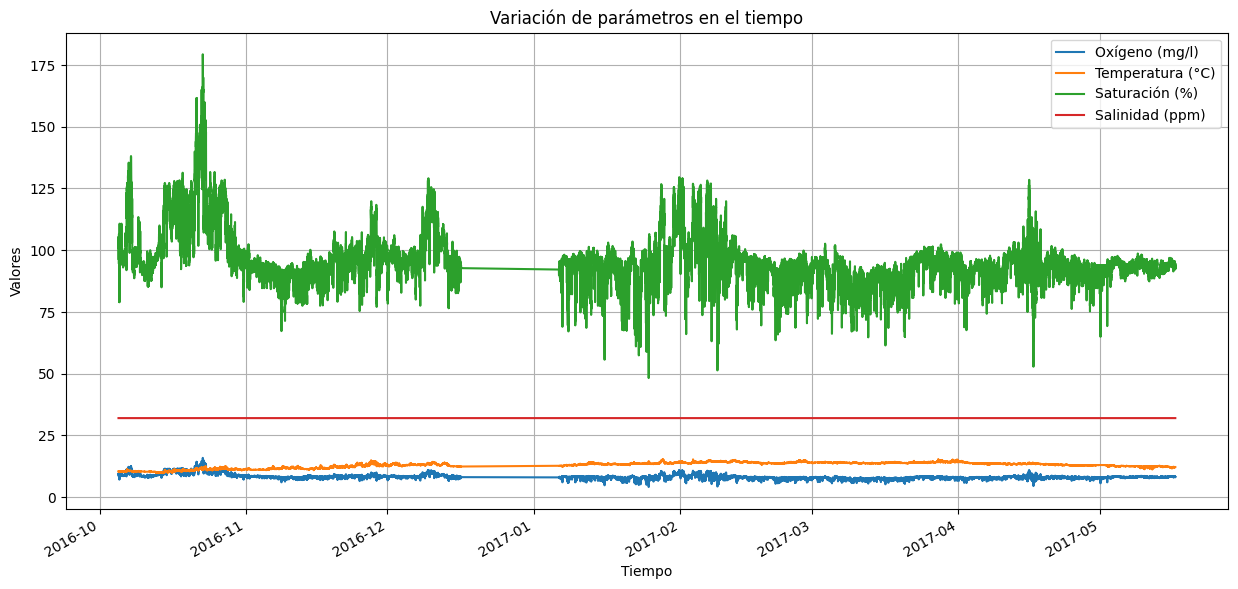

In [9]:
import matplotlib.pyplot as plt

# Combinar las columnas 'Fecha' y 'Hora' en una sola columna de tipo datetime
data['Datetime'] = pd.to_datetime(data['Fecha'] + ' ' + data['Hora'], dayfirst=True)

# Establecer 'Datetime' como índice
data.set_index('Datetime', inplace=True)

# Seleccionar las columnas a graficar
columns_to_plot = ['Oxígeno (mg/l)', 'Temperatura (°C)', 'Saturación (%)', 'Salinidad (ppm)']

# Crear el gráfico
data[columns_to_plot].plot(figsize=(15, 7), title="Variación de parámetros en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valores")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
# Select features (independent variables) and target (dependent variable)
X = data[[
    'Temperatura (°C)'
    # , 'Saturación (%)'
    , 'Salinidad (ppm)'
          ]]
dummy = data['Hora'].apply(lambda x: 
    # set the time of day to 1 if it's between 6:00 and 18:00, and 0 otherwise
    1 if 6 <= int(x.split(':')[0]) < 18 else 0)

X['Hora'] = dummy
X = X.values


y = data['Oxígeno (mg/l)'].values

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate the model
score = model.score(X_test, y_test)
print(f"Model R^2 score: {score}")

# Predict oxygen values
y_pred = model.predict(X_test)

# Display the first few predictions
print("Predicted values:", y_pred[:5])
print("Actual values:", y_test[:5])


Model R^2 score: 0.19052103582910118
Predicted values: [7.88920849 8.13643396 7.95253646 8.10988549 7.95253646]
Actual values: [6.1 8.5 7.1 7.  7.4]


/var/folders/dw/z6n4z03n4pb1msq_pnwhsf3m0000gq/T/ipykernel_29883/427840930.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Hora'] = dummy


In [23]:
# describe the model coefficients, including the dummy variable 'Hora'
coefficients = model.coef_
intercept = model.intercept_
print("Model coefficients:")
for feature, coef in zip(['Temperatura (°C)', 'Hora', 'Salinidad (ppm)'], coefficients):
    print(f"{feature}: {coef}")
print(f"Intercept: {intercept}")

Model coefficients:
Temperatura (°C): -0.36779500429634693
Hora: 0.0
Salinidad (ppm): 0.0470105331796777
Intercept: 13.028107515975435


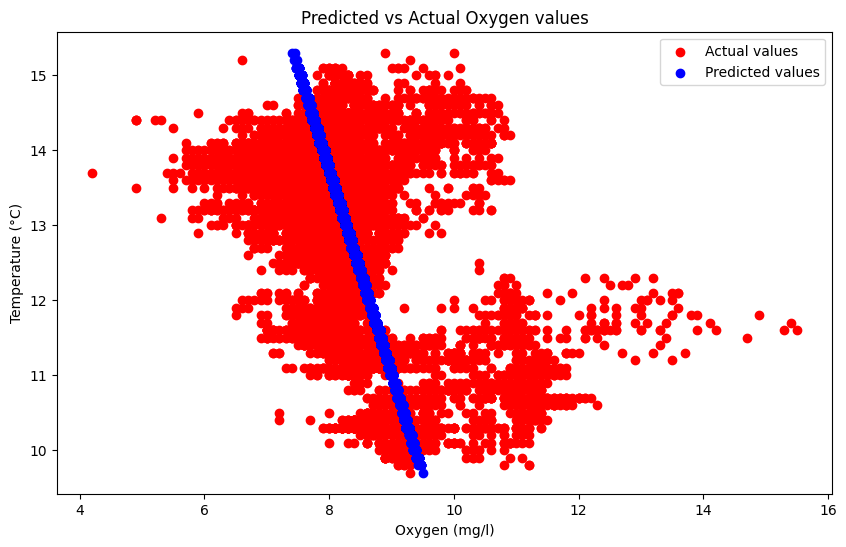

In [26]:
# Plot the predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, X_test[:, 0], color='red', label='Actual values')
plt.scatter(y_pred, X_test[:, 0], color='blue', label='Predicted values')
plt.xlabel('Oxygen (mg/l)')
plt.ylabel('Temperature (°C)')
plt.title('Predicted vs Actual Oxygen values')
plt.legend()

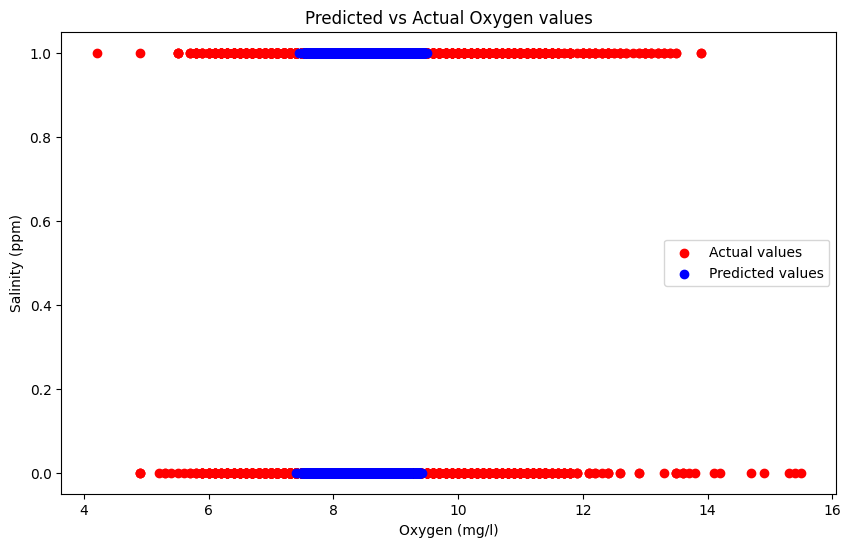

In [28]:
# graficar la relación con la salinidad
plt.figure(figsize=(10, 6))
plt.scatter(y_test, X_test[:, 2], color='red', label='Actual values')
plt.scatter(y_pred, X_test[:, 2], color='blue', label='Predicted values')
plt.xlabel('Oxygen (mg/l)')
plt.ylabel('Salinity (ppm)')
plt.title('Predicted vs Actual Oxygen values')
plt.legend()
plt.show()

In [30]:
X_test

array([[14.1, 32. ,  1. ],
       [13.3, 32. ,  0. ],
       [13.8, 32. ,  0. ],
       ...,
       [13.5, 32. ,  1. ],
       [13.8, 32. ,  0. ],
       [13.8, 32. ,  1. ]], shape=(11653, 3))

<Figure size 1000x600 with 0 Axes>

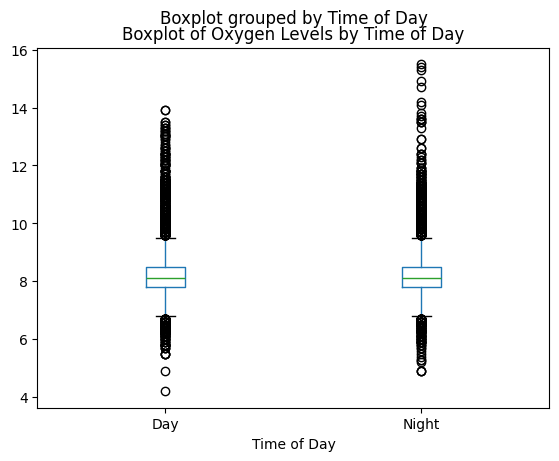

In [34]:
# graficar la relación con la hora del día
plt.figure(figsize=(10, 6))
# Create a boxplot to visualize the relationship with the time of day

# Convert the dummy variable back to a categorical column for better visualization
time_of_day = ['Day' if val == 1 else 'Night' for val in X_test[:, 2]]

# Create a DataFrame for plotting
plot_data = pd.DataFrame({'Oxygen (mg/l)': y_test, 'Time of Day': time_of_day})

# Plot the boxplot
plot_data.boxplot(column='Oxygen (mg/l)', by='Time of Day', grid=False)
plt.title('Boxplot of Oxygen Levels by Time of Day')
plt.show()


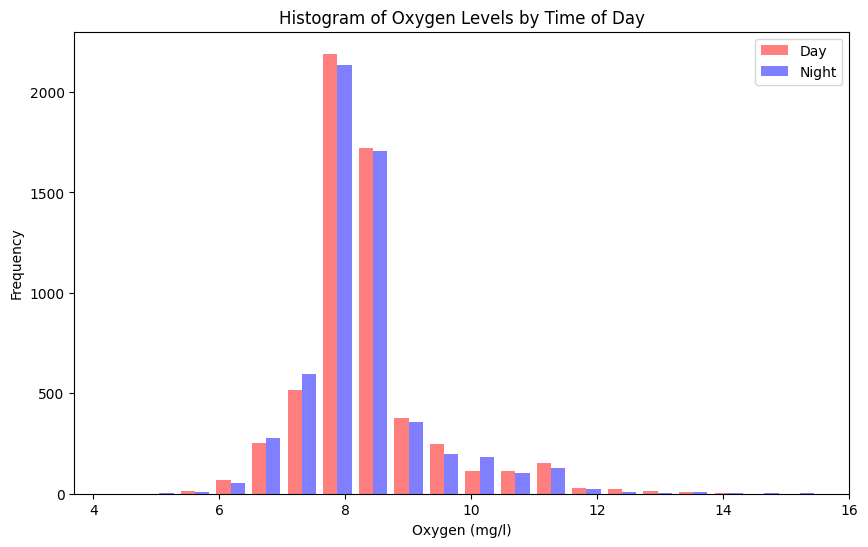

In [41]:
import numpy as np

# Convert time_of_day to a NumPy array for indexing
time_of_day = np.array(['Day' if val == 1 else 'Night' for val in X_test[:, 2]])

# Histogram relation between oxygen and hour
plt.figure(figsize=(10, 6))

# Create a histogram to visualize the relationship with the time of day
plt.hist([y_test[time_of_day == 'Day'], y_test[time_of_day == 'Night']],
         bins=20, 
         color=['red', 'blue'], 
         label=['Day', 'Night'], 
         alpha=0.5,
         stacked=False
         )
plt.xlabel('Oxygen (mg/l)')
plt.ylabel('Frequency')
plt.title('Histogram of Oxygen Levels by Time of Day')
plt.legend()
plt.show()


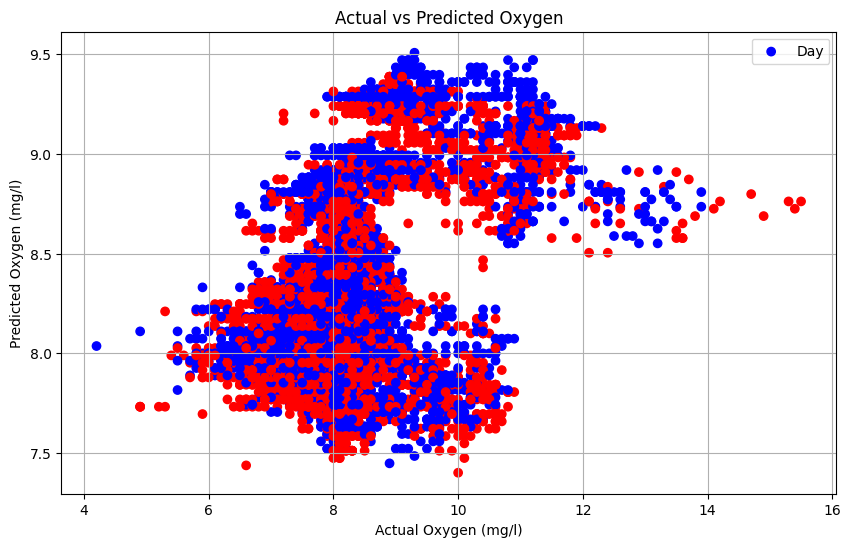

In [46]:
# Plot the predicted vs actual values
plt.figure(figsize=(10, 6))

# Map the numerical values in X_test[:, 2] to colors
colors = ['red' if val == 0 else 'blue' for val in X_test[:, 2]]

plt.scatter(y_test, y_pred, color=colors)
plt.xlabel('Actual Oxygen (mg/l)')
plt.ylabel('Predicted Oxygen (mg/l)')
plt.legend(['Day', 'Night'])
plt.title('Actual vs Predicted Oxygen')
plt.grid()
plt.show()